<a href="https://colab.research.google.com/github/MarianoZamora95/Analisis-de-Ventas/blob/main/analisis_ventas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Exploratorio de Ventas

## Objetivo

El objetivo de este proyecto es realizar un análisis exploratorio de un conjunto de datos de ventas utilizando Python y posteriormente desarrollar un dashboard interactivo en Data Studio para visualizar los principales indicadores del negocio.

## Herramientas utilizadas

- Python
- Pandas
- Matplotlib
- Excel
- Data Studio
- Jupyter Notebook

## Contenido del proyecto

El dataset contiene información sobre ventas realizadas, incluyendo la fecha de la operación, cliente, país, producto, valor de la venta y método de pago.

Este conjunto de datos será utilizado para realizar un análisis exploratorio y obtener indicadores clave del negocio.

- Importación de librerías
- Carga de datos
- Exploración inicial
- Calidad de los datos
- Indicadores (KPIs)
- Análisis exploratorio
- Visualizaciones
- Dashboard en Data Studio

# 1. Importación de librerías

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Carga de datos

In [4]:
df = pd.read_excel("BD Ventas.xlsx")
print(df.head())

       Fecha   Año  Mes        Cliente       País    Producto  Valor  \
0 2019-01-01  2019  ene    Juan Garcia      Chile  Producto B    350   
1 2019-01-01  2019  ene    Maria Lopez   Colombia  Producto C    200   
2 2019-01-01  2019  ene    Clara Oliva     México  Producto C    200   
3 2019-01-01  2019  ene  Agustina Saez  Argentina  Producto C    200   
4 2019-01-01  2019  ene     Jose Muñoz     España  Producto D    600   

             MétodoDePago  
0  Transferencia bancaria  
1       Tarjeta de débito  
2  Transferencia bancaria  
3      Tarjeta de crédito  
4  Transferencia bancaria  


# 3. Exploración inicial

In [5]:
print("Dimensiones:", df.shape)
df.info()
print(df.describe())
print(df.columns)

Dimensiones: (11999, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11999 entries, 0 to 11998
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Fecha         11999 non-null  datetime64[ns]
 1   Año           11999 non-null  int64         
 2   Mes           11999 non-null  object        
 3   Cliente       11999 non-null  object        
 4   País          11999 non-null  object        
 5   Producto      11999 non-null  object        
 6   Valor         11999 non-null  int64         
 7   MétodoDePago  11999 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(5)
memory usage: 750.1+ KB
                               Fecha           Año         Valor
count                          11999  11999.000000  11999.000000
mean   2020-07-04 21:18:49.594132736   2020.006751    412.880240
min              2019-01-01 00:00:00   2019.000000    200.000000
25%              2019-10-05 00:00:00 

# 4. Calidad de los datos

En esta sección se verifica la integridad del dataset analizando valores nulos, registros duplicados y tipos de datos.

In [6]:
df.isnull().sum()

,0
Fecha,0
Año,0
Mes,0
Cliente,0
País,0
Producto,0
Valor,0
MétodoDePago,0


### Conclusión

El dataset no presenta valores nulos, por lo que no fue necesario realizar imputaciones de datos.

In [7]:
df.dtypes

,0
Fecha,datetime64[ns]
Año,int64
Mes,object
Cliente,object
País,object
Producto,object
Valor,int64
MétodoDePago,object


In [8]:
df.nunique()

,0
Fecha,1096
Año,3
Mes,12
Cliente,11999
País,5
Producto,4
Valor,4
MétodoDePago,3


In [9]:
df.duplicated().sum()

np.int64(0)

### Conclusión

No se detectaron registros duplicados, por lo que no fue necesario eliminar observaciones repetidas.

# Indicadores principales (KPIs)

## Total de ventas

In [10]:
ventas_totales = df["Valor"].sum()
print(f"Ventas Totales: ${ventas_totales:,.2f}")

Ventas Totales: $4,954,150.00


## Ticket promedio

In [11]:
ticket_promedio = df["Valor"].mean()
print(f"Ticket Promedio: ${ticket_promedio:,.2f}")

Ticket Promedio: $412.88


## Indicador: Venta máxima

In [12]:
venta_maxima = df["Valor"].max()
print(f"Venta Máxima: ${venta_maxima:,.2f}")

Venta Máxima: $600.00


### Conclusión

La venta de mayor importe registrada en el dataset fue de $600.00. Este indicador permite conocer el valor máximo alcanzado en una única transacción.

## Venta mínima

In [13]:
venta_minima = df["Valor"].min()
print(f"Venta Mínima: ${venta_minima:,.2f}")

Venta Mínima: $200.00


### Conclusión

La venta de menor importe registrada en el dataset fue de $200.00. Este indicador permite conocer el valor mínimo alcanzado en una única transacción.

## Cantidad de ventas

In [14]:
cantidad_ventas = len(df)
print(f"Cantidad de ventas: {cantidad_ventas}")

Cantidad de ventas: 11999


## Conclusión general de los indicadores

Los indicadores obtenidos permiten tener una primera visión del comportamiento de las ventas. Se identificó el volumen total facturado, el ticket promedio, los valores extremos de las transacciones y la cantidad total de ventas registradas. Estos resultados servirán como base para el análisis exploratorio y las visualizaciones posteriores.

# 5. Análisis Exploratorio y Visualizaciones

En esta sección se profundiza en el comportamiento de las ventas a través de gráficos interactivos, analizando el rendimiento por país, los métodos de pago preferidos por los clientes y la evolución temporal de los ingresos.

## Gráfico 1. Ventas por País
Este gráfico muestra la distribución del total de ventas por país para identificar los mercados con mayor participación.

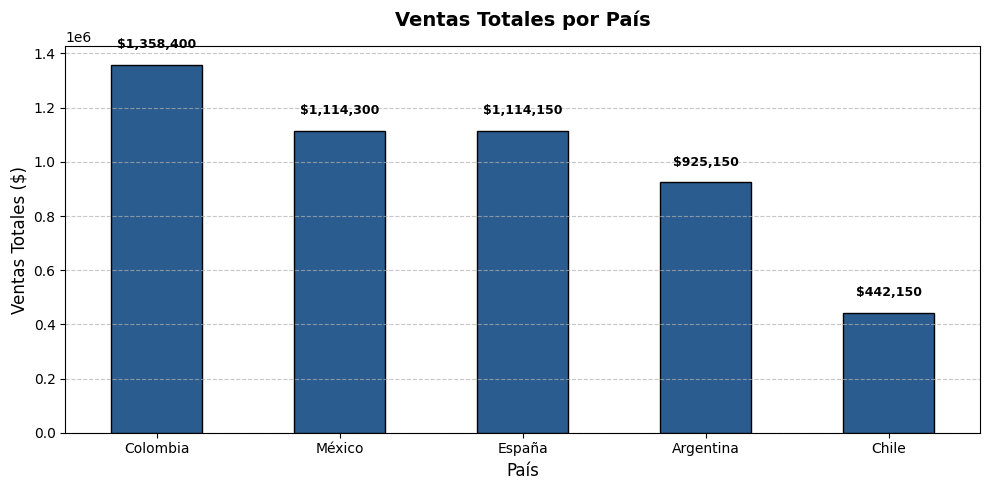

In [15]:
# Agrupar las ventas por país y sumar el valor
ventas_pais = df.groupby("País")["Valor"].sum().sort_values(ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(10, 5))
ventas_pais.plot(kind="bar", color="#2b5c8f", edgecolor="black")

# Personalización del gráfico
plt.title("Ventas Totales por País", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("País", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)
plt.xticks(rotation=0)  # Evita que los nombres de los países se inclinen
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar valores sobre las barras
for i, v in enumerate(ventas_pais):
    plt.text(i, v + 50000, f"${v:,.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Gráfico 2. Métodos de Pago más Utilizados
Ideal para entender el comportamiento de transacciones de tus clientes.

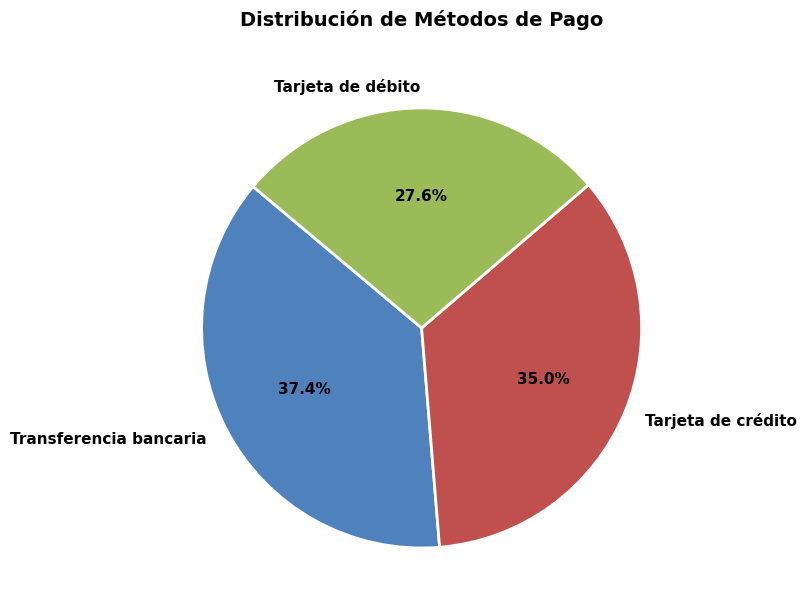

In [16]:
# Contar la frecuencia de cada método de pago
metodos_pago = df.groupby("MétodoDePago")["Valor"].sum().sort_values(ascending=False)

# Crear gráfico de pastel (pie chart)
plt.figure(figsize=(8, 8))
colors = ["#4f81bd", "#c0504d", "#9bbb59"]
plt.pie(metodos_pago, labels=metodos_pago.index, autopct='%1.1f%%', startangle=140, colors=colors,
        textprops={'fontsize': 11, 'weight': 'bold'}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})

plt.title("Distribución de Métodos de Pago", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

## Gráfico 3. Tendencia Temporal de Ventas
Para ver si el negocio está creciendo mes a mes a lo largo de los 3 años de registros.

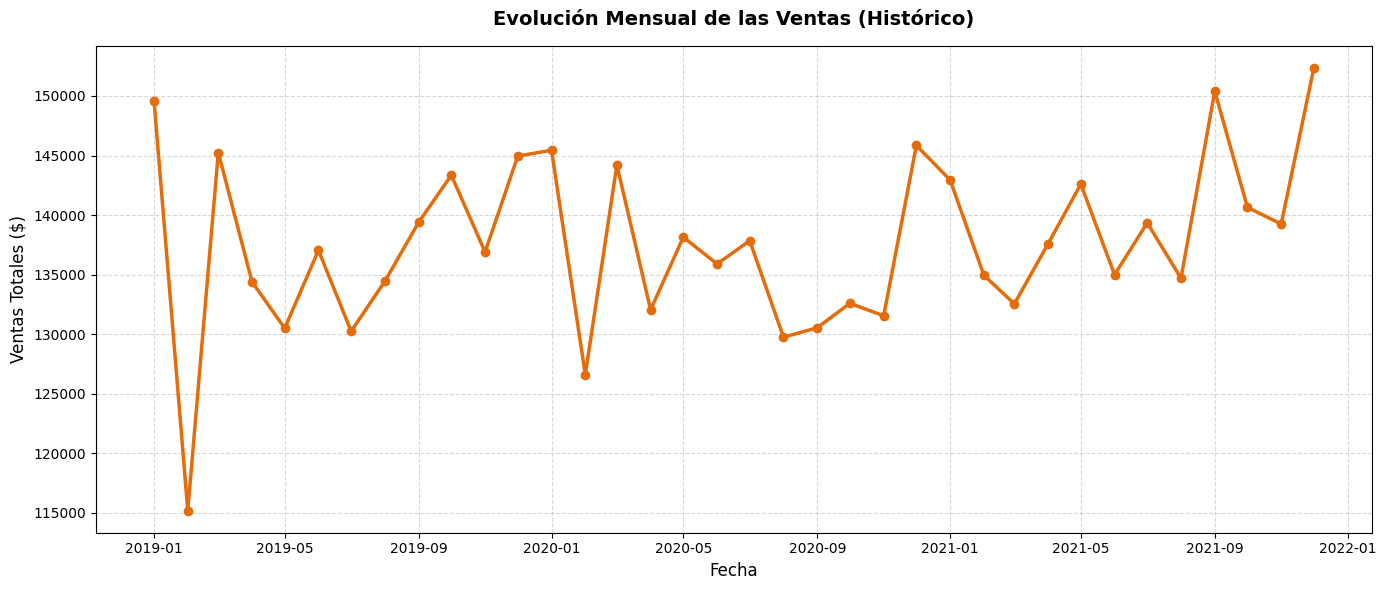

In [17]:
# Agrupar las ventas por año y mes
ventas_mensuales = df.groupby(df["Fecha"].dt.to_period("M"))["Valor"].sum()

# Convertir el índice a formato timestamp para graficar correctamente
ventas_mensuales.index = ventas_mensuales.index.to_timestamp()

# Crear gráfico de línea
plt.figure(figsize=(14, 6))
plt.plot(ventas_mensuales.index, ventas_mensuales.values, marker="o", color="#e46c0a", linewidth=2.5)

# Personalización
plt.title("Evolución Mensual de las Ventas (Histórico)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Fecha", fontsize=12)
plt.ylabel("Ventas Totales ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# 6. Dashboard de Análisis de Ventas

Con los datos analizados en Python se desarrolló un dashboard interactivo en Data Studio para visualizar los principales indicadores de ventas.

El dashboard incluye:

- Ventas Totales
- Cantidad de Ventas
- Ticket Promedio
- Ventas por País
- Ventas por Producto
- Distribución por Método de Pago
- Evolución Mensual de las Ventas
- Filtros por País, Producto y Método de Pago



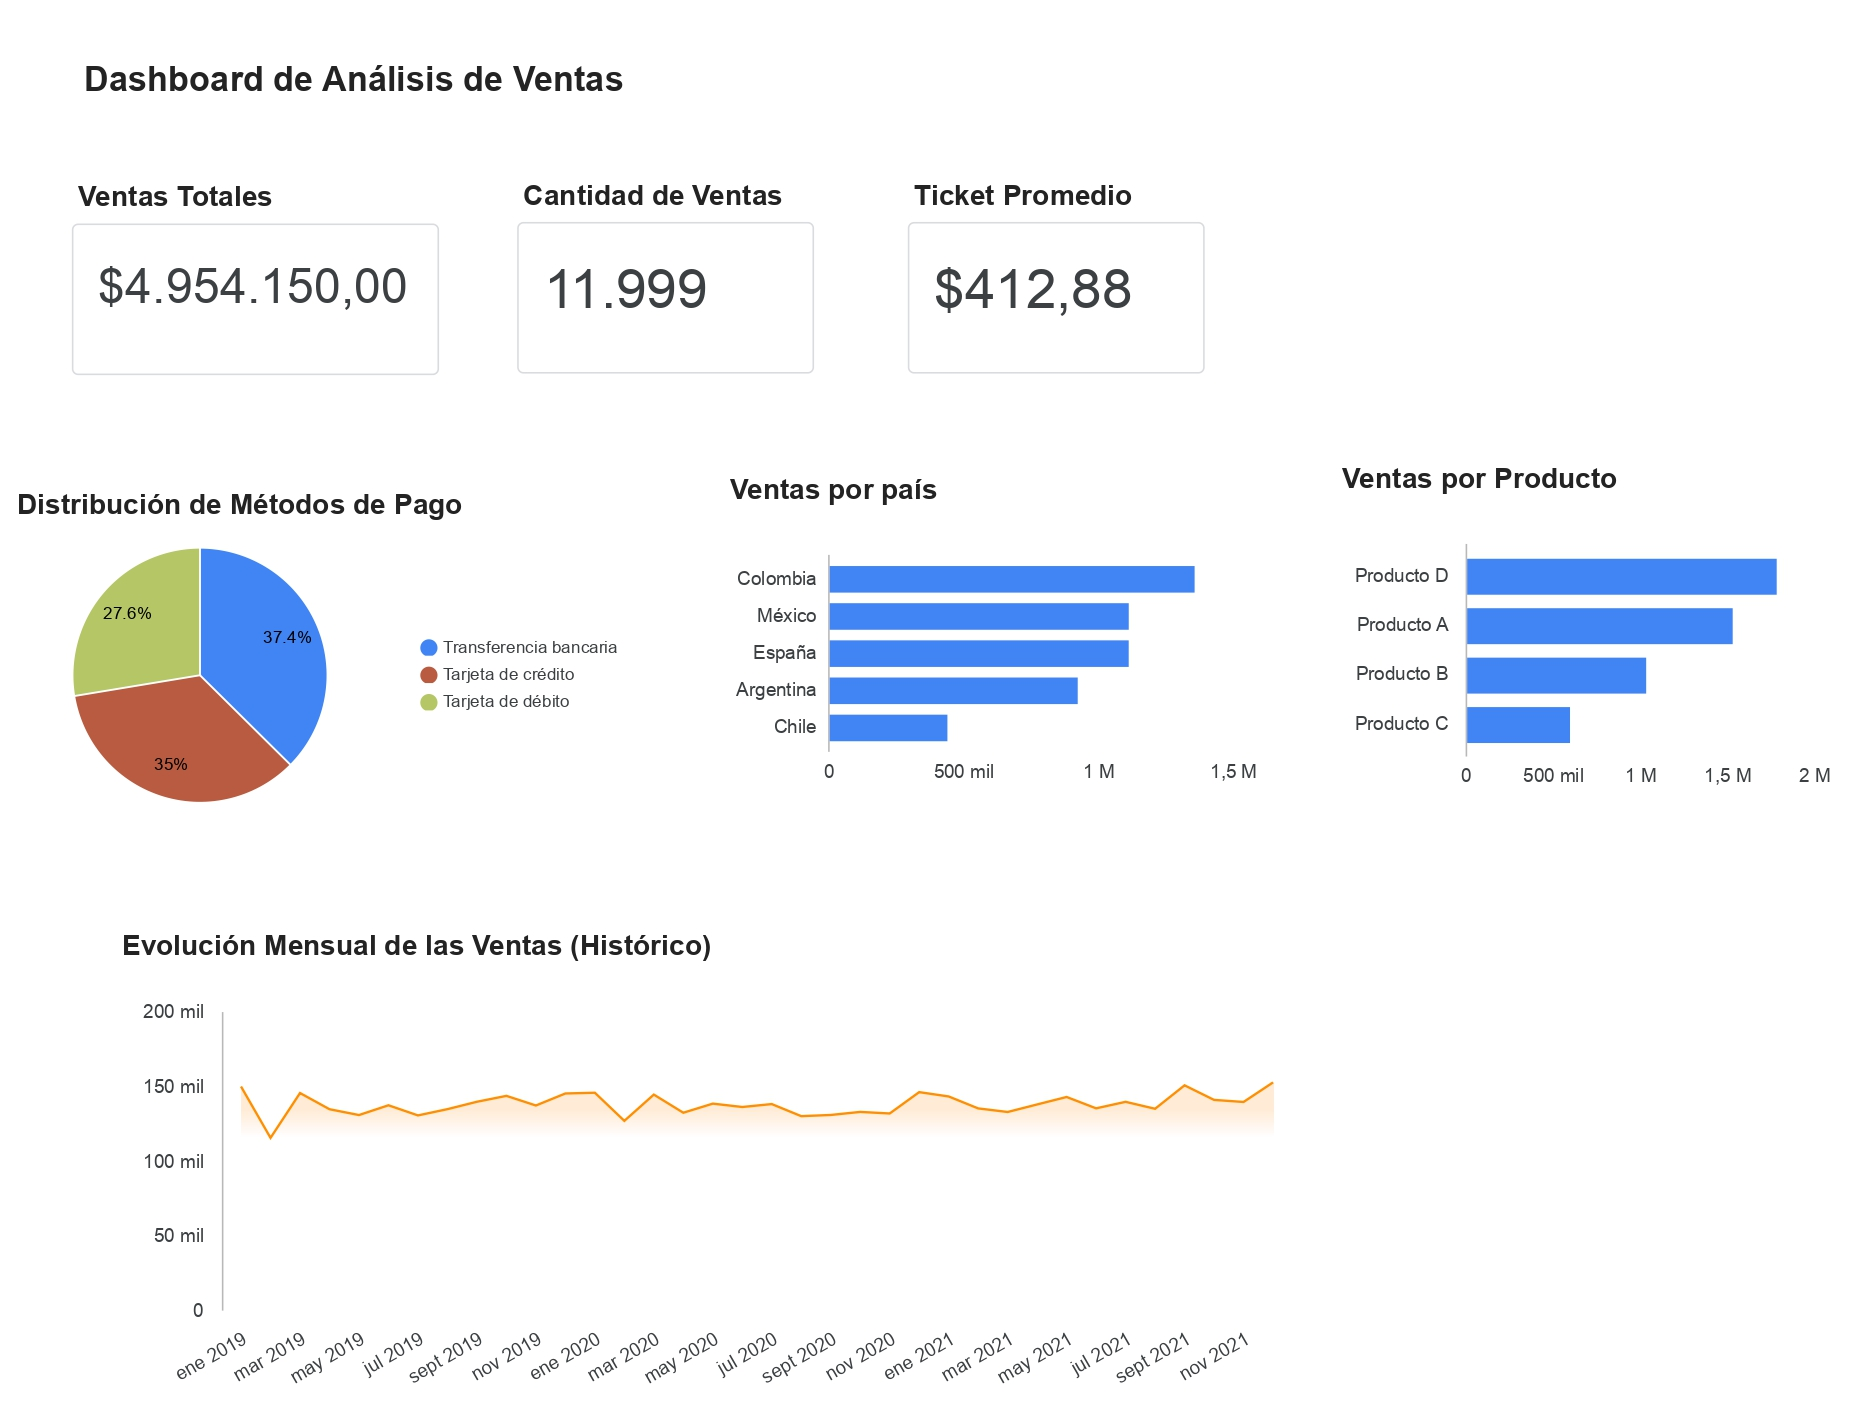

In [18]:
from IPython.display import Image, display

display(Image("dashboard.jpg"))

## Dashboard Interactivo

El dashboard interactivo fue desarrollado en Data Studio y puede consultarse en el siguiente enlace:

**🔗 Dashboard:** https://datastudio.google.com/u/0/reporting/34d63601-547c-45ac-8560-b3087e307984/page/rEB4F

# 7. Conclusión Final

Este proyecto permitió aplicar el proceso completo de análisis de datos, desde la exploración y limpieza del conjunto de datos hasta el cálculo de indicadores clave (KPIs) y la creación de visualizaciones.

Como resultado, se desarrolló un dashboard interactivo en Data Studio que resume los principales indicadores comerciales y facilita la interpretación de la información para apoyar el análisis de las ventas.

Este proyecto integra herramientas de Python (pandas y matplotlib) junto con Data Studio para transformar datos en información útil y presentarla de forma clara mediante un dashboard interactivo.